In [ ]:
 import pandas as pd
 from sklearn.preprocessing import StandardScaler
 from sklearn.model_selection import train_test_split
 from keras.models import Sequential
 from keras.layers import Dense, Dropout
 from keras.callbacks import EarlyStopping
 import matplotlib.pyplot as plt
 import io

In [ ]:
 from google.colab import files
 uploaded = files.upload()

Saving BostonHousing.csv to BostonHousing.csv


In [ ]:
 df = pd.read_csv(io.BytesIO(uploaded['BostonHousing.csv']))  # Use correct filename
 df = df.rename(columns=str.upper)  # Make all column names uppercase
 print(df.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

   LSTAT  MEDV  CAT. MEDV  
0   4.98  24.0          0  
1   9.14  21.6          0  
2   4.03  34.7          1  
3   2.94  33.4          1  
4   5.33  36.2          1  


In [ ]:
 X = df.drop(['MEDV', 'CAT. MEDV'], axis=1)  # Drop target and categorical columns
 y = df['MEDV']
 scaler = StandardScaler()
 X_scaled = scaler.fit_transform(X)
 print(X_scaled[:5])

[[-0.41978194  0.28482986 -1.2879095  -0.27259857 -0.14421743  0.41367189
  -0.12001342  0.1402136  -0.98284286 -0.66660821 -1.45900038 -1.0755623 ]
 [-0.41733926 -0.48772236 -0.59338101 -0.27259857 -0.74026221  0.19427445
   0.36716642  0.55715988 -0.8678825  -0.98732948 -0.30309415 -0.49243937]
 [-0.41734159 -0.48772236 -0.59338101 -0.27259857 -0.74026221  1.28271368
  -0.26581176  0.55715988 -0.8678825  -0.98732948 -0.30309415 -1.2087274 ]
 [-0.41675042 -0.48772236 -1.30687771 -0.27259857 -0.83528384  1.01630251
  -0.80988851  1.07773662 -0.75292215 -1.10611514  0.1130321  -1.36151682]
 [-0.41248185 -0.48772236 -1.30687771 -0.27259857 -0.83528384  1.22857665
  -0.51117971  1.07773662 -0.75292215 -1.10611514  0.1130321  -1.02650148]]


In [ ]:
 X_train, X_test, y_train, y_test = train_test_split(
 X_scaled, y, test_size=0.3, random_state=42
 )
 print('Training set shape:', X_train.shape, y_train.shape)
 print('Testing set shape:', X_test.shape, y_test.shape)

Training set shape: (354, 12) (354,)
Testing set shape: (152, 12) (152,)


In [ ]:
 model = Sequential([
 Dense(64, input_dim=X.shape[1], activation='relu'),
 Dropout(0.2),
 Dense(32, activation='relu'),
 Dense(1)  # Output for regression
 ])
 model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])
 model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
 early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
 history = model.fit(
 X_train, y_train,
 validation_split=0.2,
 epochs=100,
 batch_size=32,
 callbacks=[early_stopping],
 verbose=1
 )

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 601.7524 - mean_absolute_error: 22.5286 - val_loss: 555.5981 - val_mean_absolute_error: 22.1272
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 568.7458 - mean_absolute_error: 22.1278 - val_loss: 532.7085 - val_mean_absolute_error: 21.6356
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 570.0618 - mean_absolute_error: 21.9626 - val_loss: 505.2189 - val_mean_absolute_error: 21.0309
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 503.2179 - mean_absolute_error: 20.5092 - val_loss: 470.5813 - val_mean_absolute_error: 20.2409
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 494.3617 - mean_absolute_error: 20.1906 - val_loss: 426.2536 - val_mean_absolute_error: 19.1841
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 456.7391 - mean_absolute_error: 19.0828 - val_loss: 372.8145 - val_mean_absolute_error: 17.8259
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 376.7670 - mean_ab

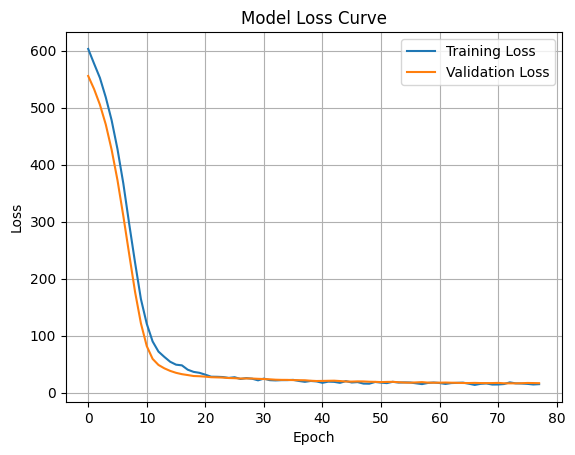

In [ ]:
 plt.plot(history.history['loss'], label='Training Loss')
 plt.plot(history.history['val_loss'], label='Validation Loss')
 plt.title('Model Loss Curve')
 plt.xlabel('Epoch')
 plt.ylabel('Loss')
 plt.legend()
 plt.grid(True)
 plt.savefig("loss_plot.png")
 plt.show()